In [17]:
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
import xgboost as xgb

from matplotlib import pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.calibration import cross_val_predict

In [2]:
s2_path = "datasets/WESAD/S2/S2.pkl"
# we have to change the encoding because the data appears to have been
# pickled with py2 and we are in py 3
with open(s2_path, 'rb') as file:
    s2_data = pickle.load(file, encoding='latin1')

In [3]:
c_ax=s2_data['signal']['chest']['ACC'][0:,0]
c_ay=s2_data['signal']['chest']['ACC'][0:,1]
c_az=s2_data['signal']['chest']['ACC'][0:,2]
c_ecg=s2_data['signal']['chest']['ECG'][:,0]
c_emg=s2_data['signal']['chest']['EMG'][:,0]
c_eda=s2_data['signal']['chest']['EDA'][:,0]
c_temp=s2_data['signal']['chest']['Temp'][:,0]
c_resp=s2_data['signal']['chest']['Resp'][:,0]

w_ax=s2_data['signal']['wrist']['ACC'][0:,0]
w_ay=s2_data['signal']['wrist']['ACC'][0:,1]
w_az=s2_data['signal']['wrist']['ACC'][0:,2]
w_bvp=s2_data['signal']['wrist']['BVP'][:,0]
w_eda=s2_data['signal']['wrist']['EDA'][:,0]
w_temp=s2_data['signal']['wrist']['TEMP'][:,0]
w_label=s2_data['label']

In [4]:
numpy_data1=np.array([c_ax, c_ay, c_az,c_ecg,c_emg,c_eda,c_temp,c_resp,w_label])
numpy_data1=numpy_data1.T

df = pd.DataFrame(data=numpy_data1, columns=["c_ax", "c_ay", "c_az","c_ecg","c_emg","c_eda","c_temp","c_resp","w_label"]) 

Removing Outliers

In [5]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
print("IQR is\n", IQR)

IQR is
 c_ax       0.271200
c_ay       0.054000
c_az       0.507400
c_ecg      0.112335
c_emg      0.012314
c_eda      0.746918
c_temp     1.240173
c_resp     3.100586
w_label    2.000000
dtype: float64


In [6]:
df_out = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(df_out.shape)

(2100456, 9)


In [7]:
y=df_out.w_label
x=df_out.drop('w_label',axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

Normalization

In [8]:
#mean normalization:
# norm_df_out=(df_out-df_out.mean())/df_out.std()

#min-max normalization:
norm_df_out=(df_out-df_out.min())/(df_out.max()-df_out.min())

norm_y = df_out.w_label #keep original labels Dont normalize labels
norm_x = norm_df_out.drop('w_label',axis=1)

norm_x_train,norm_x_test,norm_y_train,norm_y_test=train_test_split(norm_x,norm_y,test_size=0.2)

In [9]:
norm_df_out.head()

,c_ax,c_ay,c_az,c_ecg,c_emg,c_eda,c_temp,c_resp,w_label
393691,0.328829,0.790741,0.152413,0.426141,0.381395,0.993931,0.000585,0.416585,0.25
394476,0.326577,0.773148,0.157444,0.132539,0.248372,0.992174,0.000289,0.648868,0.25
395154,0.325143,0.789815,0.155676,0.642522,0.740465,0.998243,0.000868,0.359498,0.25
396635,0.321048,0.751852,0.150238,0.217808,0.544186,0.998083,0.000289,0.695374,0.25
402178,0.324939,0.778704,0.152005,0.628260,0.406512,0.992174,0.021382,0.664247,0.25


Training Basic Models

In [10]:

# Logistic Regression Model
clf_lr = LogisticRegression(solver='newton-cg', penalty='l2')
clf_lr.fit(norm_x_train, norm_y_train)
y_pred = clf_lr.predict(norm_x_test)
print("Logistic Regression Performance:")
print(classification_report(norm_y_test, y_pred, digits=4))

Logistic Regression Performance:
              precision    recall  f1-score   support

         0.0     0.8220    0.8927    0.8559    245893
         1.0     0.9746    0.9037    0.9378     10947
         2.0     0.6998    0.4010    0.5099     63320
         3.0     0.7902    0.8169    0.8034     47892
         4.0     0.9113    1.0000    0.9536     52040

    accuracy                         0.8235    420092
   macro avg     0.8396    0.8029    0.8121    420092
weighted avg     0.8150    0.8235    0.8120    420092



In [11]:

# K Nearest Neighbors Model
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(norm_x_train, norm_y_train)
y_pred = clf_knn.predict(norm_x_test)
print("K-Nearest Neighbors Performance:")
print(classification_report(norm_y_test, y_pred, digits=4))


K-Nearest Neighbors Performance:
              precision    recall  f1-score   support

         0.0     0.9910    0.9770    0.9840    245893
         1.0     0.9994    0.9905    0.9949     10947
         2.0     0.9692    0.9857    0.9774     63320
         3.0     0.9669    0.9875    0.9771     47892
         4.0     0.9619    0.9889    0.9752     52040

    accuracy                         0.9813    420092
   macro avg     0.9777    0.9859    0.9817    420092
weighted avg     0.9816    0.9813    0.9814    420092



In [12]:

# Decision Tree Classifier Model
clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt.fit(norm_x_train, norm_y_train)
y_pred = clf_dt.predict(norm_x_test)
print("Decision Tree Classifier Performance:")
print(classification_report(norm_y_test, y_pred, digits=4))


Decision Tree Classifier Performance:
              precision    recall  f1-score   support

         0.0     0.9924    0.9921    0.9922    245893
         1.0     0.9994    0.9984    0.9989     10947
         2.0     0.9911    0.9913    0.9912     63320
         3.0     0.9911    0.9913    0.9912     47892
         4.0     0.9818    0.9830    0.9824     52040

    accuracy                         0.9909    420092
   macro avg     0.9911    0.9912    0.9912    420092
weighted avg     0.9909    0.9909    0.9909    420092



In [13]:

# Random Forest Classifier Model
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(norm_x_train, norm_y_train)
y_pred = clf_rf.predict(norm_x_test)
print("Random Forest Classifier Performance:")
print(classification_report(norm_y_test, y_pred, digits=4))


Random Forest Classifier Performance:
              precision    recall  f1-score   support

         0.0     0.9966    0.9940    0.9953    245893
         1.0     1.0000    1.0000    1.0000     10947
         2.0     0.9923    0.9984    0.9953     63320
         3.0     0.9938    0.9961    0.9949     47892
         4.0     0.9869    0.9893    0.9881     52040

    accuracy                         0.9945    420092
   macro avg     0.9939    0.9956    0.9947    420092
weighted avg     0.9945    0.9945    0.9945    420092



In [ ]:
# SVC classifier Model -----!
clf_svc = SVC(kernel='linear', C=1, random_state=0)
clf_svc.fit(x_train, y_train)
y_pred = clf_svc.predict(x_test)
print("SVC Classifier Performance:")
print(classification_report(y_test, y_pred, digits=4))

In [15]:
# XGBoost Model

#https://towardsdatascience.com/https-medium-com-vishalmorde-xgboost-algorithm-long-she-may-rein-edd9f99be63d
#https://www.datacamp.com/community/tutorials/xgboost-in-python
#https://medium.com/@gabrielziegler3/multiclass-multilabel-classification-with-xgboost-66195e4d9f2d

clf_xgb = xgb.XGBClassifier(eval_metric='mlogloss')
clf_xgb.fit(norm_x_train, norm_y_train)
y_pred = clf_xgb.predict(norm_x_test)
print("XGBoost Classifier Performance:")
print(classification_report(norm_y_test, y_pred, digits=4))

XGBoost Classifier Performance:
              precision    recall  f1-score   support

         0.0     0.9961    0.9929    0.9945    245893
         1.0     0.9999    0.9995    0.9997     10947
         2.0     0.9901    0.9970    0.9935     63320
         3.0     0.9916    0.9952    0.9934     47892
         4.0     0.9866    0.9900    0.9883     52040

    accuracy                         0.9936    420092
   macro avg     0.9929    0.9949    0.9939    420092
weighted avg     0.9936    0.9936    0.9936    420092



In [19]:
base_models_dir = 'models/base_models'
os.makedirs(base_models_dir, exist_ok=True)

# Save the models
joblib.dump(clf_lr, base_models_dir + '/clf_lr.pkl')
joblib.dump(clf_knn, base_models_dir + '/clf_knn.pkl')
joblib.dump(clf_dt, base_models_dir + '/clf_dt.pkl')
joblib.dump(clf_rf, base_models_dir + '/clf_rf.pkl')
# joblib.dump(clf_svc, base_models_dir + '/clf_svc.pkl')
joblib.dump(clf_xgb, base_models_dir + '/clf_xgb.pkl')

['models/base_models/clf_xgb.pkl']

With Cross Validation

In [ ]:
# Logistic Regression Model
clf_lr = LogisticRegression(solver='newton-cg', penalty='l2')
clf_lr.fit(norm_x_train, norm_y_train)
norm_y_out = cross_val_predict(clf_lr, norm_x, norm_y, cv=10)
print("Logistic Regression Performance:")
print(classification_report(norm_y, norm_y_out, digits=4))

In [ ]:
# K Nearest Neighbors Model
clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(norm_x_train, norm_y_train)
norm_y_out = cross_val_predict(clf_knn, norm_x, norm_y, cv=10)
print("K-Nearest Neighbors Performance:")
print(classification_report(norm_y, norm_y_out, digits=4))

In [ ]:
# Decision Tree Classifier Model
clf_dt = DecisionTreeClassifier(random_state=42)
clf_dt.fit(norm_x_train, norm_y_train)
norm_y_out = cross_val_predict(clf_dt, norm_x, norm_y, cv=10)
print("Decision Tree Classifier Performance:")
print(classification_report(norm_y, norm_y_out, digits=4))

In [ ]:
# Random Forest Classifier Model
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(norm_x_train, norm_y_train)
norm_y_out = cross_val_predict(clf_rf, norm_x, norm_y, cv=10)
print("Random Forest Classifier Performance:")
print(classification_report(norm_y, norm_y_out, digits=4))

In [ ]:
# XGBoost Model
clf_xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
clf_xgb.fit(norm_x_train, norm_y_train)
norm_y_out = cross_val_predict(clf_xgb, norm_x, norm_y, cv=10)
print("XGBoost Classifier Performance:")
print(classification_report(norm_y, norm_y_out, digits=4))

In [ ]:
""" 
Next Steps:
    Linear Discriminant Analysis (LDA)
    Quadratic Discriminant Analysis (QDA)
    Principal Component Analysis (PCA)
    Finding The Best Model
    Traning For More Data Subjects
"""

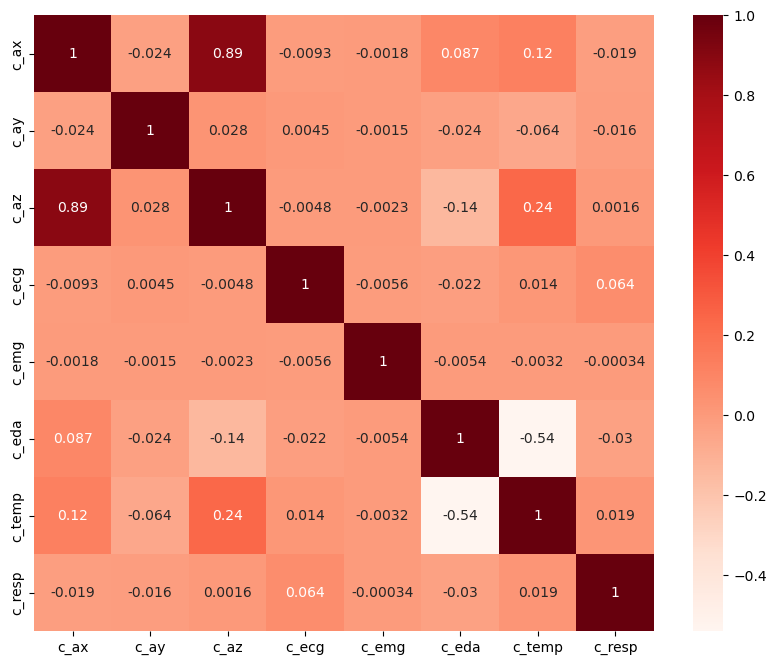

In [18]:

plt.figure(figsize=(10, 8))
cor = norm_x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

Linear Discriminant Analysis (LDA)

Quadratic Discriminant Analysis (QDA)

Principal Component Analysis (PCA)

Traning For More Data Subjects